## DataFrames Info

```
main_df : contains all data in dataset
ind_var_df : contains independent variables
dep_df : contains target variable
summary : summary of ind_var_df, including range, max_to_q3, and skewness
skew_df: DataFrame containing skewness values for independent variables
corr_df : contains correlation of all features with target variable
corr_df_sorted : corr_df sorted by correlation with target variable
strong_features : features with correlation greater than 0.02 with target variable
imb_df: DataFrame showing the proportion of 'Bankrupt?' classes
mean_df: DataFrame showing the mean of features grouped by 'Bankrupt?'
ind_dep_corr_df: Absolute correlation matrix of independent variables
upper: Upper triangle of the independent variables correlation matrix (used for multicollinearity detection)
high_corr_feature: List of features identified as highly correlated based on a threshold of 0.85
ind_var_df_selected: Independent variables after removing highly correlated features to reduce multicollinearity
X_train, X_test, y_train, y_test: Training and testing sets after splitting the data
X_train_vif: Training DataFrame used for iterative VIF calculation to remove features with high multicollinearity
vif_data: DataFrame containing VIF values for the features (updated for the final X_train_vif features)
X_test_vif: Test DataFrame with features remaining after VIF processing (matching X_train_vif columns)
X_train_resampled, y_train_resampled: Resampled training data (e.g., using SMOTE for class balancing)
X_train_resampled_vif: Resampled training DataFrame with features remaining after VIF processing

# Model Results DataFrames
all_model_results: A list to collect all model results for comparison
logistic_regression_results: A list specifically for Logistic Regression model results
k_nn_results: A list specifically for K-Nearest Neighbors model results
result_log: Results for Logistic Regression with SMOTE and Balanced Weight
best_f1_results_df: Results for Logistic Regression optimized for F1-score with a threshold
result_smote_only: Results for Logistic Regression with SMOTE only (no class weight)
logistic_final_results_df: Consolidated DataFrame of all Logistic Regression model results
result_knn: Results for a basic K-Nearest Neighbors model
results_best_knn: Results for the best K-Nearest Neighbors model found via GridSearchCV and threshold tuning
k_nn_final_results_df: Consolidated DataFrame of all K-Nearest Neighbors model results
result_dt: Results for the Decision Tree model
result_rf: Results for the Random Forest model
results_xgb_df: Results for the XGBoost model (threshold tuned for recall)
final_overall_results_df: Consolidated DataFrame of all evaluated models for final comparison
error_comparison_df: `final_overall_results_df` sorted by Type 2 Error Rate for visualization
top_models_df: Top N models based on Recall from `final_overall_results_df`
balancing_comparison_results: A list to store results for comparing different balancing techniques in Logistic Regression
lr_balancing_df: Consolidated DataFrame for comparing Logistic Regression models with different balancing techniques
```

#library imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, precision_recall_curve
from xgboost import XGBClassifier


# Initialize a list to collect all model results for comparison
all_model_results = []

# Initialize a list specifically for Logistic Regression model results
logistic_regression_results = []

# Initialize a list specifically for K-Nearest Neighbors model results
knn_results = []

In [ ]:
main_df = pd.read_csv('Dataset.csv')

#Basic analysis

In [ ]:
main_df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
list(main_df.columns)

['Bankrupt?',
 ' ROA(C) before interest and depreciation before interest',
 ' ROA(A) before interest and % after tax',
 ' ROA(B) before interest and depreciation after tax',
 ' Operating Gross Margin',
 ' Realized Sales Gross Margin',
 ' Operating Profit Rate',
 ' Pre-tax net Interest Rate',
 ' After-tax net Interest Rate',
 ' Non-industry income and expenditure/revenue',
 ' Continuous interest rate (after tax)',
 ' Operating Expense Rate',
 ' Research and development expense rate',
 ' Cash flow rate',
 ' Interest-bearing debt interest rate',
 ' Tax rate (A)',
 ' Net Value Per Share (B)',
 ' Net Value Per Share (A)',
 ' Net Value Per Share (C)',
 ' Persistent EPS in the Last Four Seasons',
 ' Cash Flow Per Share',
 ' Revenue Per Share (Yuan ¥)',
 ' Operating Profit Per Share (Yuan ¥)',
 ' Per Share Net profit before tax (Yuan ¥)',
 ' Realized Sales Gross Profit Growth Rate',
 ' Operating Profit Growth Rate',
 ' After-tax Net Profit Growth Rate',
 ' Regular Net Profit Growth Rate',
 ' C

checking the proportioanlity

In [ ]:
main_df['Bankrupt?'].value_counts(normalize=True) *100

,proportion
Bankrupt?,
0,96.77372
1,3.22628


This is a highly imbalanced dataset

In [ ]:
non_bank = main_df['Bankrupt?'].value_counts()[0]
bank = main_df['Bankrupt?'].value_counts()[1]
ratio = non_bank/bank
ratio

np.float64(29.995454545454546)

Missing values

In [ ]:
missing_df  =main_df.isna().sum()

In [ ]:
missing_df[missing_df > 0].index.to_list()

[]

Plot class imbalance

Index(['Bankrupt?', 'proportion'], dtype='object')


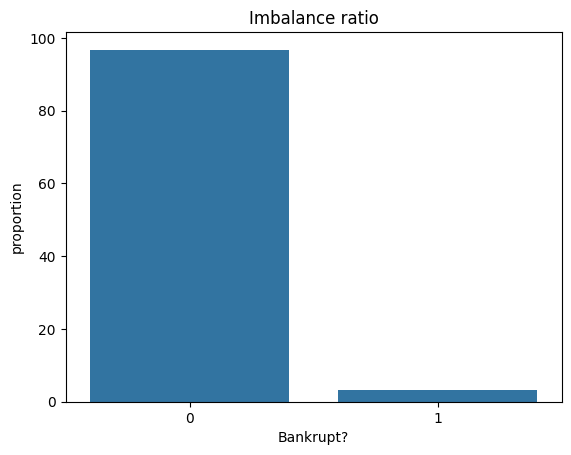

In [ ]:
imb_df = main_df['Bankrupt?'].value_counts(normalize=True) *100
imb_df = imb_df.reset_index()
print(imb_df.columns)
sns.barplot(data = imb_df,x='Bankrupt?',y= 'proportion')
plt.title('Imbalance ratio')
plt.show()

#Univariate analysis

In [ ]:
ind_var_df = main_df.drop('Bankrupt?',axis=1)
dep_df = main_df['Bankrupt?']

In [ ]:
summary = ind_var_df.describe().T.reset_index().rename(columns={'index': 'cols'})
summary

,cols,count,mean,std,min,25%,50%,75%,max
0,ROA(C) before interest and depreciation befor...,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
1,ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
2,ROA(B) before interest and depreciation after...,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
3,Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
4,Realized Sales Gross Margin,6819.0,0.607929,0.016916,0.0,0.600434,0.605976,0.613842,1.0
...,...,...,...,...,...,...,...,...,...
90,Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
91,Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
92,Interest Coverage Ratio (Interest expense to ...,6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
93,Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


##Checking outliers<br>
- range
- 75 percentile
- skew

In [ ]:
summary['range'] = summary['max'] - summary['min']
summary['max_to_q3'] = summary['max'] - summary['75%']
summary

,cols,count,mean,std,min,25%,50%,75%,max,range,max_to_q3
0,ROA(C) before interest and depreciation befor...,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0,1.0,0.464437
1,ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0,1.0,0.410843
2,ROA(B) before interest and depreciation after...,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0,1.0,0.415895
3,Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0,1.0,0.386086
4,Realized Sales Gross Margin,6819.0,0.607929,0.016916,0.0,0.600434,0.605976,0.613842,1.0,1.0,0.386158
...,...,...,...,...,...,...,...,...,...,...,...
90,Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0,1.0,0.718551
91,Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0,1.0,0.973087
92,Interest Coverage Ratio (Interest expense to ...,6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0,1.0,0.434275
93,Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0,0.0,0.000000


In [ ]:
skew_df = ind_var_df.skew().reset_index().rename(columns={'index': 'cols', 0: 'skew'})
skew_df.head()

,cols,skew
0,ROA(C) before interest and depreciation befor...,-0.323941
1,ROA(A) before interest and % after tax,-1.033727
2,ROA(B) before interest and depreciation after...,-0.763564
3,Operating Gross Margin,-8.043368
4,Realized Sales Gross Margin,-8.066572


In [ ]:
summary = summary.merge(on='cols',right=skew_df,how='left')

In [ ]:
len(summary[abs(summary['skew'])>2]) # getting highly skewed values

73

#Bivariate analysis

check mean absolute error

In [ ]:
mean_df = main_df.groupby('Bankrupt?').mean().T
mean_df = mean_df.reset_index(names=['Bankrupt?'])

In [ ]:
mean_df


Bankrupt?,Bankrupt?,0,1
0,ROA(C) before interest and depreciation befor...,0.508069,0.418503
1,ROA(A) before interest and % after tax,0.562015,0.456947
2,ROA(B) before interest and depreciation after...,0.556659,0.461483
3,Operating Gross Margin,0.608257,0.598670
4,Realized Sales Gross Margin,0.608237,0.598717
...,...,...,...
90,Liability to Equity,0.279925,0.293578
91,Degree of Financial Leverage (DFL),0.027511,0.028443
92,Interest Coverage Ratio (Interest expense to ...,0.565371,0.564959
93,Net Income Flag,1.000000,1.000000


In [ ]:
mean_df['difference'] = abs(mean_df[1] - mean_df[0])
mean_df.sort_values(by='difference', ascending=False).head(15)

Bankrupt?,Bankrupt?,0,1,difference
48,Fixed Assets Turnover Frequency,9.756574e+08,1.996603e+09,1.020945e+09
28,Total Asset Growth Rate,5.531603e+09,4.803017e+09,7.285860e+08
71,Quick Asset Turnover Rate,2.147829e+09,2.640836e+09,4.930069e+08
11,Research and development expense rate,1.961923e+09,1.605623e+09,3.562993e+08
73,Cash Turnover Rate,2.481653e+09,2.181733e+09,2.999205e+08
58,Cash/Current Liability,2.989953e+07,2.549409e+08,2.250414e+08
70,Current Asset Turnover Rate,1.189712e+09,1.380154e+09,1.904424e+08
10,Operating Expense Rate,1.998943e+09,1.887486e+09,1.114569e+08
86,Total assets to GNP price,1.621670e+07,9.100000e+07,7.478330e+07
29,Net Value Growth Rate,2.045765e+05,4.240909e+07,4.220451e+07


As the scale of values are too large, considering correlation between dependent and independent variable will be good

In [ ]:
corr_df = main_df.corr()['Bankrupt?'].abs().sort_values(ascending=False)[1:]
corr_df = corr_df.reset_index()
corr_df

,index,Bankrupt?
0,Net Income to Total Assets,0.315457
1,ROA(A) before interest and % after tax,0.282941
2,ROA(B) before interest and depreciation after...,0.273051
3,ROA(C) before interest and depreciation befor...,0.260807
4,Net worth/Assets,0.250161
...,...,...
90,Long-term Liability to Current Assets,0.000778
91,Cash Flow to Sales,0.000479
92,Realized Sales Gross Profit Growth Rate,0.000458
93,Operating Profit Rate,0.000230


In [ ]:
feat =  corr_df.sort_values(by = 'Bankrupt?', ascending = False)['index'][1:6]
feat

,index
1,ROA(A) before interest and % after tax
2,ROA(B) before interest and depreciation after...
3,ROA(C) before interest and depreciation befor...
4,Net worth/Assets
5,Debt ratio %


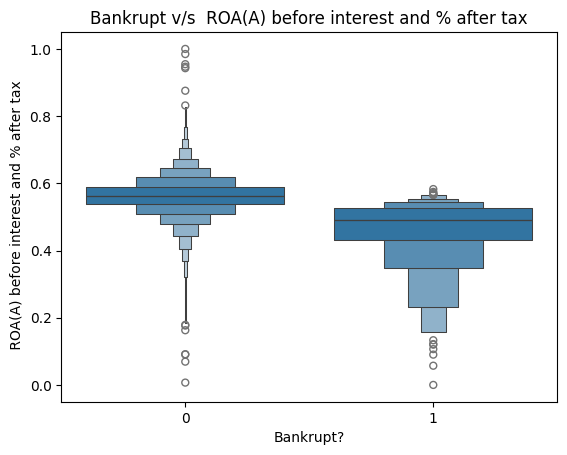

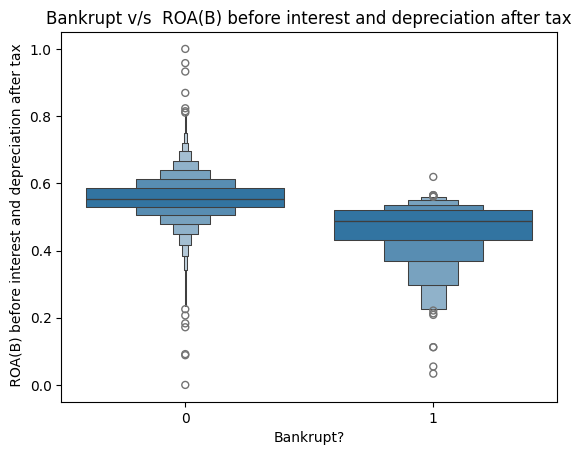

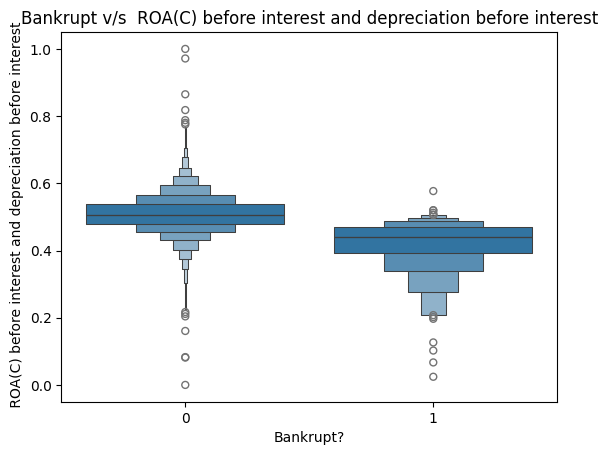

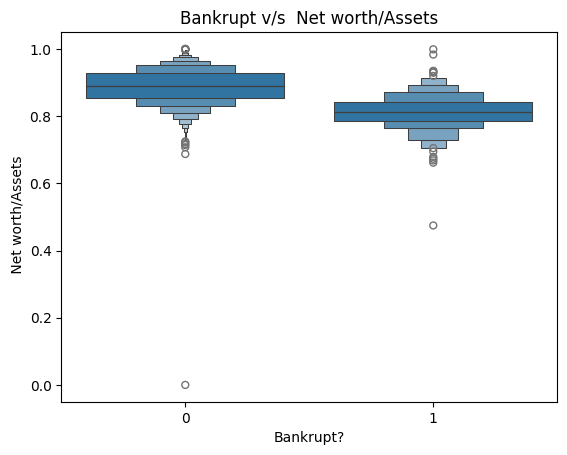

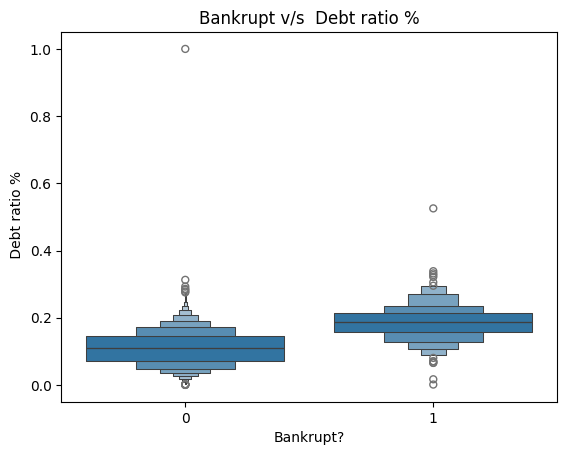

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in feat:
  sns.boxenplot(data = main_df, x = 'Bankrupt?', y = col)
  plt.title(f'Bankrupt v/s {col}')
  plt.show()

#Multicollinearity detection

In [ ]:
ind_dep_corr_df = ind_var_df.corr().abs()
ind_dep_corr_df

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
ROA(C) before interest and depreciation before interest,1.000000,0.940124,0.986849,0.334719,0.332755,0.035725,0.053419,0.049222,0.020501,0.051328,...,0.887670,0.071725,0.008135,0.334721,0.274287,0.143629,0.016575,0.010573,NaN,0.052416
ROA(A) before interest and % after tax,0.940124,1.000000,0.955741,0.326969,0.324956,0.032053,0.053518,0.049474,0.029649,0.049909,...,0.961552,0.098900,0.011463,0.326971,0.291744,0.141039,0.011515,0.013372,NaN,0.057887
ROA(B) before interest and depreciation after tax,0.986849,0.955741,1.000000,0.333749,0.331755,0.035212,0.053726,0.049952,0.022366,0.052261,...,0.912040,0.089088,0.007523,0.333750,0.280617,0.142838,0.014663,0.011473,NaN,0.056430
Operating Gross Margin,0.334719,0.326969,0.333749,1.000000,0.999518,0.005745,0.032493,0.027175,0.051438,0.029430,...,0.300143,0.022672,0.004205,1.000000,0.075304,0.085434,0.011806,0.001167,NaN,0.120029
Realized Sales Gross Margin,0.332755,0.324956,0.331755,0.999518,1.000000,0.005610,0.032232,0.026851,0.051242,0.029166,...,0.298155,0.022750,0.004038,0.999518,0.074891,0.085407,0.011268,0.001158,NaN,0.120196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Liability to Equity,0.143629,0.141039,0.142838,0.085434,0.085407,0.001541,0.004043,0.004390,0.011899,0.002996,...,0.159697,0.021982,0.003724,0.085434,0.791836,1.000000,0.002119,0.001487,NaN,0.159654
Degree of Financial Leverage (DFL),0.016575,0.011515,0.014663,0.011806,0.011268,0.000935,0.000855,0.000927,0.000556,0.000774,...,0.010463,0.001881,0.008812,0.011806,0.000093,0.002119,1.000000,0.016513,NaN,0.016739
Interest Coverage Ratio (Interest expense to EBIT),0.010573,0.013372,0.011473,0.001167,0.001158,0.000393,0.000984,0.000957,0.001024,0.000798,...,0.012746,0.000239,0.001027,0.001169,0.005147,0.001487,0.016513,1.000000,NaN,0.008339
Net Income Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


consider only upper triangle fo the matrix to avoid redundancy<br>
**0.85** should be a threshold to consider correlation between independent variables( we need those with lower correlation)

In [ ]:
upper = ind_dep_corr_df.where(
    np.triu(np.ones(ind_dep_corr_df.shape), k=1).astype(bool)
)

In [ ]:
upper

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
ROA(C) before interest and depreciation before interest,NaN,0.940124,0.986849,0.334719,0.332755,0.035725,0.053419,0.049222,0.020501,0.051328,...,0.887670,0.071725,0.008135,0.334721,0.274287,0.143629,0.016575,0.010573,NaN,0.052416
ROA(A) before interest and % after tax,NaN,NaN,0.955741,0.326969,0.324956,0.032053,0.053518,0.049474,0.029649,0.049909,...,0.961552,0.098900,0.011463,0.326971,0.291744,0.141039,0.011515,0.013372,NaN,0.057887
ROA(B) before interest and depreciation after tax,NaN,NaN,NaN,0.333749,0.331755,0.035212,0.053726,0.049952,0.022366,0.052261,...,0.912040,0.089088,0.007523,0.333750,0.280617,0.142838,0.014663,0.011473,NaN,0.056430
Operating Gross Margin,NaN,NaN,NaN,NaN,0.999518,0.005745,0.032493,0.027175,0.051438,0.029430,...,0.300143,0.022672,0.004205,1.000000,0.075304,0.085434,0.011806,0.001167,NaN,0.120029
Realized Sales Gross Margin,NaN,NaN,NaN,NaN,NaN,0.005610,0.032232,0.026851,0.051242,0.029166,...,0.298155,0.022750,0.004038,0.999518,0.074891,0.085407,0.011268,0.001158,NaN,0.120196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Liability to Equity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.002119,0.001487,NaN,0.159654
Degree of Financial Leverage (DFL),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016513,NaN,0.016739
Interest Coverage Ratio (Interest expense to EBIT),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008339
Net Income Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
high_corr_feature = [col for col in upper.columns if any(upper[col] >0.85)]
high_corr_feature

[' ROA(A) before interest and % after tax',
 ' ROA(B) before interest and depreciation after tax',
 ' Realized Sales Gross Margin',
 ' Pre-tax net Interest Rate',
 ' After-tax net Interest Rate',
 ' Continuous interest rate (after tax)',
 ' Net Value Per Share (A)',
 ' Net Value Per Share (C)',
 ' Operating Profit Per Share (Yuan ¥)',
 ' Per Share Net profit before tax (Yuan ¥)',
 ' Regular Net Profit Growth Rate',
 ' Net worth/Assets',
 ' Operating profit/Paid-in capital',
 ' Net profit before tax/Paid-in capital',
 ' Operating Funds to Liability',
 ' Current Liabilities/Equity',
 ' Cash Flow to Sales',
 ' Current Liability to Liability',
 ' Current Liability to Equity',
 ' Net Income to Total Assets',
 ' Gross Profit to Sales',
 ' Liability to Equity']

In [ ]:
corr_df_sorted = corr_df.sort_values(by='Bankrupt?', ascending=False)
strong_features = corr_df_sorted[corr_df_sorted['Bankrupt?'] > 0.02]['index']

In [ ]:
strong_features

,index
0,Net Income to Total Assets
1,ROA(A) before interest and % after tax
2,ROA(B) before interest and depreciation after...
3,ROA(C) before interest and depreciation befor...
4,Net worth/Assets
...,...
58,Research and development expense rate
59,Interest-bearing debt interest rate
60,Net Worth Turnover Rate (times)
61,Current Liabilities/Liability


actually some features have good correlation with target variable but as they belong to similar class the correlation between variables of similar class is good which is not acceptable for logistic regression so it's better to have one variable from that particular class

In [ ]:
selected = []
threshold = 0.85

for feature in strong_features:
    if feature == 'Bankrupt?':
        continue

    if all(abs(ind_var_df[feature].corr(ind_var_df[sel])) < threshold for sel in selected):
        selected.append(feature)

In [ ]:
ind_var_df_selected = ind_var_df[selected]

In [ ]:
len(selected)

45

After multicollinearity analysis the less important features are removed and now the number of features are reduced to 45 from 96


#Data Splitting and class balancing

##Data splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(ind_var_df_selected, dep_df, test_size=0.2, random_state=42, stratify=dep_df)

To avoid data leake we should just do feature extraction form training data

##Applying VIF

In [ ]:
X_train_vif = X_train.copy()

# Impute missing values (NaN) and infinite values (inf) in X_train_vif before VIF calculation
# Using median imputation as it is robust to outliers
for col in X_train_vif.columns:
    if X_train_vif[col].isnull().any() or np.isinf(X_train_vif[col]).any():
        median_val = X_train_vif[col][np.isfinite(X_train_vif[col])].median()
        X_train_vif[col] = X_train_vif[col].replace([np.inf, -np.inf], median_val)
        X_train_vif[col] = X_train_vif[col].fillna(median_val)

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['Features'] = X.columns
    # Ensure no constant columns are passed, as VIF cannot be calculated for them
    X_no_const = X.loc[:, (X != X.iloc[0]).any()]
    vif_data['VIF'] = [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
    return vif_data

# Iteratively remove features with VIF > 10
while True:
    vif_data = calculate_vif(X_train_vif)
    max_vif = vif_data['VIF'].max()
    if max_vif > 10:
        drop_feat = vif_data.sort_values('VIF', ascending=False).iloc[0]['Features']
        print(f"Dropping {drop_feat} with VIF={max_vif:.2f}")
        X_train_vif = X_train_vif.drop(columns=[drop_feat])
    else:
        break

print(f"Remaining features: {X_train_vif.shape[1]}")

Dropping  Current Liability to Assets with VIF=1973.92
Dropping  Working Capital/Equity with VIF=88546.63
Dropping  Inventory and accounts receivable/Net value with VIF=9176.45
Dropping  Retained Earnings to Total Assets with VIF=4535.79
Dropping  Borrowing dependency with VIF=2671.09
Dropping  Gross Profit to Sales with VIF=2127.12
Dropping  After-tax Net Profit Growth Rate with VIF=1962.60
Dropping  Cash Flow to Equity with VIF=1119.99
Dropping  Working Capital to Total Assets with VIF=8923.05
Dropping  Net Income to Stockholder's Equity with VIF=3328.97
Dropping  Net Income to Total Assets with VIF=1239.23
Dropping  Cash Flow Per Share with VIF=1232.98
Dropping  Cash Reinvestment % with VIF=1054.47
Dropping  Cash Flow to Liability with VIF=581.67
Dropping  Net worth/Assets with VIF=391.83
Dropping  Operating Funds to Liability with VIF=310.56
Dropping  Cash Flow to Total Assets with VIF=183.71
Dropping  Operating profit per person with VIF=155.82
Dropping  Persistent EPS in the Last

reduced to 21 features now

#Models

##common functions with pipeline

In [ ]:
def model_pipeline(
    X_train,y_train,X_test,y_test,model,
    model_name = 'model',
    scale = False,
    use_smote = False,
    test_size = 0.2,
    random_state = 42):
  steps = []
  if scale:
    steps.append(('scale',StandardScaler()))
  if use_smote:
    steps.append(('smote',SMOTE(random_state=random_state)))
  steps.append(('model',model))

  pipeline = Pipeline(steps)
  pipeline.fit(X_train,y_train)
  y_pred = pipeline.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  tn, fp, fn, tp = cm.ravel()

  # Calculate Type 2 Error Rate here
  type_2_error_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

  results = {
        "Model": model_name,
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "False Negatives": fn,
        "True Positives": tp,
        "False Positives": fp,
        "True Negatives": tn,
        "Type 2 Error Rate": type_2_error_rate # Added Type 2 Error Rate
    }

  return pipeline, pd.DataFrame([results])

##Logistic regression with VIF

In [ ]:
X_test_vif = X_test[X_train_vif.columns]
logi = LogisticRegression(max_iter = 1000,class_weight="balanced")
model_log, result_log = model_pipeline( X_train_vif,y_train,X_test_vif,y_test, # Corrected X_test to X_test_vif
                                       model = logi,
                                       model_name = "Logistic Regression (SMOTE + Balanced Weight)",
                                       scale = True,use_smote = True)

# The Type 2 Error Rate is now calculated within model_pipeline, so these lines are no longer needed
# cm_log = confusion_matrix(y_test, model_log.predict(X_test_vif))
# tn_log, fp_log, fn_log, tp_log = cm_log.ravel()
# result_log['Type 2 Error Rate'] = fn_log / (fn_log + tp_log)

logistic_regression_results.append(result_log)
display(result_log)


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,Logistic Regression (SMOTE + Balanced Weight),0.818182,0.145161,0.246575,0.83871,8,36,212,1108,0.181818


precision is too low which means non bankrupt companies are marked otherwise trying to change threshold now

In [ ]:
pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [ ]:
pipeline.fit(X_train_vif, y_train)

Pipeline(steps=[('scale', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_prob = pipeline.predict_proba(X_test_vif)[:, 1]

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

Best Threshold: 0.8129486468168109
Best F1: 0.3577231177215236


In [ ]:
y_pred_final = (y_prob >= 0.8129).astype(int)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1320
           1       0.28      0.50      0.36        44

    accuracy                           0.94      1364
   macro avg       0.63      0.73      0.66      1364
weighted avg       0.96      0.94      0.95      1364



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, precision_recall_curve

# y_prob and y_test are assumed to be available from previous steps

# Define the thresholds to test
thresholds_to_test = [0.4, 0.6]

for threshold_value in thresholds_to_test:
    print(f"\n--- Evaluating with threshold: {threshold_value:.2f} ---")
    y_pred_fixed_threshold = (y_prob >= threshold_value).astype(int)
    print(classification_report(y_test, y_pred_fixed_threshold))


--- Evaluating with threshold: 0.40 ---
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      1320
           1       0.12      0.86      0.21        44

    accuracy                           0.79      1364
   macro avg       0.56      0.83      0.54      1364
weighted avg       0.97      0.79      0.86      1364


--- Evaluating with threshold: 0.60 ---
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1320
           1       0.16      0.68      0.26        44

    accuracy                           0.88      1364
   macro avg       0.58      0.78      0.60      1364
weighted avg       0.96      0.88      0.91      1364



This is again recall heavy.let's try other sets of values for threshold
`[0.5, 0.6, 0.7, 0.75]`

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# y_prob and y_test are assumed to be available from previous steps

# Define the range of thresholds to test
start_threshold = 0.4
end_threshold = best_threshold  # Using the previously calculated best_threshold
step_size = 0.01

# Generate thresholds to test, ensuring best_threshold is included
thresholds_to_test = np.arange(start_threshold, end_threshold + step_size, step_size)

for threshold_value in thresholds_to_test:
    print(f"\n--- Evaluating with threshold: {threshold_value:.2f} ---")
    y_pred_current_threshold = (y_prob >= threshold_value).astype(int)
    print(classification_report(y_test, y_pred_current_threshold))


--- Evaluating with threshold: 0.40 ---
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      1320
           1       0.12      0.86      0.21        44

    accuracy                           0.79      1364
   macro avg       0.56      0.83      0.54      1364
weighted avg       0.97      0.79      0.86      1364


--- Evaluating with threshold: 0.41 ---
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      1320
           1       0.12      0.86      0.21        44

    accuracy                           0.80      1364
   macro avg       0.56      0.83      0.55      1364
weighted avg       0.97      0.80      0.86      1364


--- Evaluating with threshold: 0.42 ---
              precision    recall  f1-score   support

           0       0.99      0.80      0.89      1320
           1       0.12      0.86      0.22        44

    accuracy                           0.80      1364
   ma

In [ ]:
y_pred_optimized_f1 = (y_prob >= best_threshold).astype(int)

# Calculate metrics for the best F1-score scenario (threshold-tuned)
recall_best_f1 = recall_score(y_test, y_pred_optimized_f1)
precision_best_f1 = precision_score(y_test, y_pred_optimized_f1)
f1_best_f1 = f1_score(y_test, y_pred_optimized_f1)
accuracy_best_f1 = accuracy_score(y_test, y_pred_optimized_f1)

cm_best_f1 = confusion_matrix(y_test, y_pred_optimized_f1)
tn_best_f1, fp_best_f1, fn_best_f1, tp_best_f1 = cm_best_f1.ravel()

best_f1_results_df = pd.DataFrame([{
    "Model": f"Logistic Regression (Best F1 at Threshold {best_threshold:.2f})",
    "Recall": recall_best_f1,
    "Precision": precision_best_f1,
    "F1": f1_best_f1,
    "Accuracy": accuracy_best_f1,
    "False Negatives": fn_best_f1,
    "True Positives": tp_best_f1,
    "False Positives": fp_best_f1,
    "True Negatives": tn_best_f1,
    "Type 2 Error Rate": fn_best_f1 / (fn_best_f1 + tp_best_f1)
}])

print(f"Classification Report for threshold = {best_threshold:.4f} (Optimized for F1-score):")
print(classification_report(y_test, y_pred_optimized_f1))
display(best_f1_results_df)


Classification Report for threshold = 0.8129 (Optimized for F1-score):
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1320
           1       0.28      0.50      0.36        44

    accuracy                           0.94      1364
   macro avg       0.63      0.73      0.66      1364
weighted avg       0.96      0.94      0.95      1364



,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,Logistic Regression (Best F1 at Threshold 0.81),0.5,0.278481,0.357724,0.942082,22,22,57,1263,0.5


recall for risky companies is 50% making it dangerous for investors

## Experiment 1: Logistic Regression with SMOTE (no class_weight)

In [ ]:
logi_smote_only = LogisticRegression(max_iter=1000)
model_smote_only, result_smote_only = model_pipeline(
    X_train_vif, y_train, X_test_vif, y_test,
    model=logi_smote_only,
    model_name="Logistic Regression (SMOTE Only)",
    scale=True,
    use_smote=True
)
# The Type 2 Error Rate is now calculated within model_pipeline, so these lines are no longer needed
# cm_smote_only = confusion_matrix(y_test, model_smote_only.predict(X_test_vif))
# tn_smote_only, fp_smote_only, fn_smote_only, tp_smote_only = cm_smote_only.ravel()
# result_smote_only['Type 2 Error Rate'] = fn_smote_only / (fn_smote_only + tp_smote_only)

logistic_regression_results.append(result_smote_only)
display(result_smote_only)


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,Logistic Regression (SMOTE Only),0.818182,0.145161,0.246575,0.83871,8,36,212,1108,0.181818


In [ ]:
# Create a fresh list of logistic regression results for concatenation
current_lr_results_for_display = []

# Assuming result_log and result_smote_only are the most recently updated DataFrames
# with 'Type 2 Error Rate' included, from the preceding cell executions.
current_lr_results_for_display.append(result_log)
current_lr_results_for_display.append(result_smote_only)

# Calculate metrics for the best F1-score scenario (threshold-tuned)
y_pred_best_f1_scenario = (y_prob >= best_threshold).astype(int)

recall_best_f1 = recall_score(y_test, y_pred_best_f1_scenario)
precision_best_f1 = precision_score(y_test, y_pred_best_f1_scenario)
f1_best_f1 = f1_score(y_test, y_pred_best_f1_scenario)
accuracy_best_f1 = accuracy_score(y_test, y_pred_best_f1_scenario)

cm_best_f1 = confusion_matrix(y_test, y_pred_best_f1_scenario)
tn_best_f1, fp_best_f1, fn_best_f1, tp_best_f1 = cm_best_f1.ravel()

best_f1_results_df = pd.DataFrame([{
    "Model": f"Logistic Regression (Best F1 at Threshold {best_threshold:.2f})",
    "Recall": recall_best_f1,
    "Precision": precision_best_f1,
    "F1": f1_best_f1,
    "Accuracy": accuracy_best_f1,
    "False Negatives": fn_best_f1,
    "True Positives": tp_best_f1,
    "False Positives": fp_best_f1,
    "True Negatives": tn_best_f1,
    "Type 2 Error Rate": fn_best_f1 / (fn_best_f1 + tp_best_f1)
}])

current_lr_results_for_display.append(best_f1_results_df)

# Concatenate all current logistic regression results for display
logistic_final_results_df = pd.concat(current_lr_results_for_display, ignore_index=True)

print("--- Logistic Regression Models Comparison ---")
display(logistic_final_results_df)

# Now, populate the global `logistic_regression_results` list (if still needed for other parts)
# Ensure it's cleared first to avoid duplicates or old data
logistic_regression_results.clear() # Clear the global list
logistic_regression_results.extend(current_lr_results_for_display) # Add the cleaned list


--- Logistic Regression Models Comparison ---


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,Logistic Regression (SMOTE + Balanced Weight),0.818182,0.145161,0.246575,0.838710,8,36,212,1108,0.181818
1,Logistic Regression (SMOTE Only),0.818182,0.145161,0.246575,0.838710,8,36,212,1108,0.181818
2,Logistic Regression (Best F1 at Threshold 0.81),0.500000,0.278481,0.357724,0.942082,22,22,57,1263,0.500000


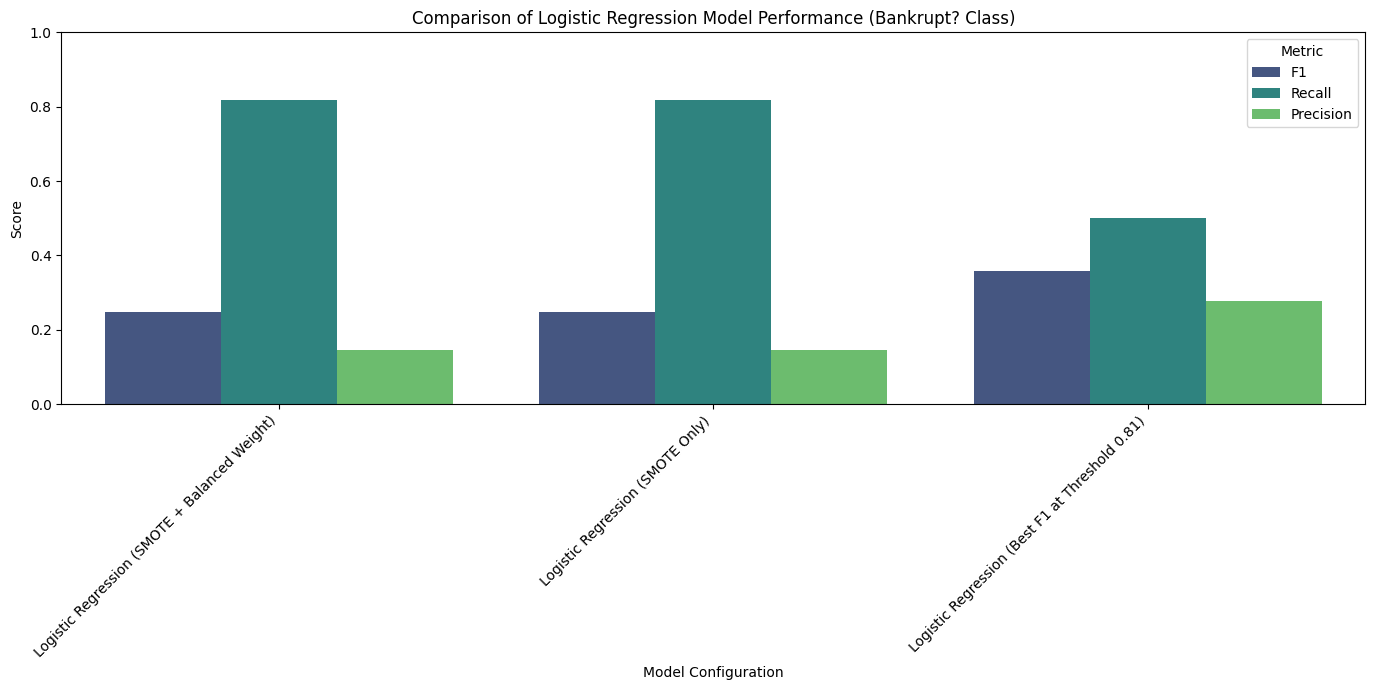


--- Consolidated Overall Model Results ---


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,Logistic Regression (Best F1 at Threshold 0.81),0.500000,0.278481,0.357724,0.942082,22,22,57,1263,0.500000
1,Logistic Regression (SMOTE + Balanced Weight),0.818182,0.145161,0.246575,0.838710,8,36,212,1108,0.181818
2,Logistic Regression (SMOTE Only),0.818182,0.145161,0.246575,0.838710,8,36,212,1108,0.181818


In [ ]:
plt.figure(figsize=(14, 7))
metrics = ['F1', 'Recall', 'Precision']

logistic_results_melted = logistic_final_results_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

sns.barplot(x='Model', y='Score', hue='Metric', data=logistic_results_melted, palette='viridis')
plt.title('Comparison of Logistic Regression Model Performance (Bankrupt? Class)')
plt.ylabel('Score')
plt.xlabel('Model Configuration')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# CENTRALIZED COLLECTION OF ALL MODEL RESULTS FOR FINAL COMPARISON
all_model_results = [] # Clear the list to ensure no duplicates from previous runs

# 1. Add Logistic Regression results
all_model_results.append(best_f1_results_df) # Best F1 LR
all_model_results.append(result_log) # SMOTE + Balanced Weight LR (highest recall LR)
all_model_results.append(result_smote_only) # SMOTE Only LR


# Consolidate all results into the final DataFrame
final_overall_results_df = pd.concat(all_model_results, ignore_index=True)

print("\n--- Consolidated Overall Model Results ---")
display(final_overall_results_df)

## K- Nearest Neighbours

In [ ]:
knn_model = KNeighborsClassifier()
model_knn, result_knn = model_pipeline(
    X_train_vif, y_train, X_test_vif, y_test,
    model=knn_model,
    model_name="K-Nearest Neighbors (SMOTE + Scaled)",
    scale=True,
    use_smote=True
)
# This basic KNN result is not directly added to all_model_results for final comparison;
# only the optimized KNN result (from 281eKPa5EWH3) will be used.
display(result_knn)


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,K-Nearest Neighbors (SMOTE + Scaled),0.636364,0.17284,0.271845,0.890029,16,28,134,1186,0.363636


In [ ]:
knn_model = KNeighborsClassifier()
model_knn, result_knn = model_pipeline(
    X_train_vif, y_train, X_test_vif, y_test,
    model=knn_model,
    model_name="K-Nearest Neighbors (SMOTE + Scaled)",
    scale=True,
    use_smote=True
)
# This basic KNN result is not directly added to all_model_results for final comparison;
# only the optimized KNN result (from 281eKPa5EWH3) will be used.
display(result_knn)


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,K-Nearest Neighbors (SMOTE + Scaled),0.636364,0.17284,0.271845,0.890029,16,28,134,1186,0.363636


using GridSearchCV to find optimal amount of nieghbours for the model

In [ ]:
knn_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('smote', SMOTE(sampling_strategy=0.3, random_state=42)),  # controlled balancing
    ('knn', KNeighborsClassifier())
])

# -------------------------------
# HYPERPARAMETER GRID
# -------------------------------
param_grid_knn = {
    'knn__n_neighbors': range(3, 21),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # Manhattan vs Euclidean
}

# -------------------------------
# CROSS-VALIDATION
# -------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid_knn,
    scoring='recall',  # prioritize recall (Type 2 error reduction)
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Train
grid_search_knn.fit(X_train_vif, y_train)

print("Best KNN Parameters:", grid_search_knn.best_params_)
print("Best CV Recall:", grid_search_knn.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best KNN Parameters: {'knn__n_neighbors': 20, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV Recall: 0.5742857142857142


In [ ]:
best_knn_model = grid_search_knn.best_estimator_
y_prob_knn = best_knn_model.predict_proba(X_test_vif)[:, 1]


In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_knn)

# Align lengths
precisions = precisions[:-1]
recalls = recalls[:-1]

# Compute F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Apply recall constraint
valid_idxs = np.where(recalls >= 0.75)[0]

if len(valid_idxs) > 0:
    best_idx = valid_idxs[np.argmax(f1_scores[valid_idxs])]
else:
    best_idx = np.argmax(recalls)

best_threshold_knn = thresholds[best_idx]

print(f"Best Threshold for KNN: {best_threshold_knn:.4f}")

# Final predictions
y_pred_knn = (y_prob_knn >= best_threshold_knn).astype(int)

# -------------------------------
# METRICS
# -------------------------------
cm_knn = confusion_matrix(y_test, y_pred_knn)
tn_knn, fp_knn, fn_knn, tp_knn = cm_knn.ravel()

results_best_knn = {
    "Model": f"KNN (Optimized Recall, n={grid_search_knn.best_params_['knn__n_neighbors']})",
    "Recall": recall_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "F1": f1_score(y_test, y_pred_knn),
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "False Negatives": fn_knn,
    "True Positives": tp_knn,
    "False Positives": fp_knn,
    "True Negatives": tn_knn,
    "Type 2 Error Rate": fn_knn / (fn_knn + tp_knn)
}

knn_results.append(pd.DataFrame([results_best_knn])) # Append to knn_results for KNN comparison

print("\n--- Improved KNN Results ---")
display(pd.DataFrame([results_best_knn]))


Best Threshold for KNN: 0.4231

--- Improved KNN Results ---


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,"KNN (Optimized Recall, n=20)",0.75,0.221477,0.341969,0.906891,11,33,116,1204,0.25


--- KNN Models Comparison ---


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,"KNN (Optimized Recall, n=20)",0.75,0.221477,0.341969,0.906891,11,33,116,1204,0.25


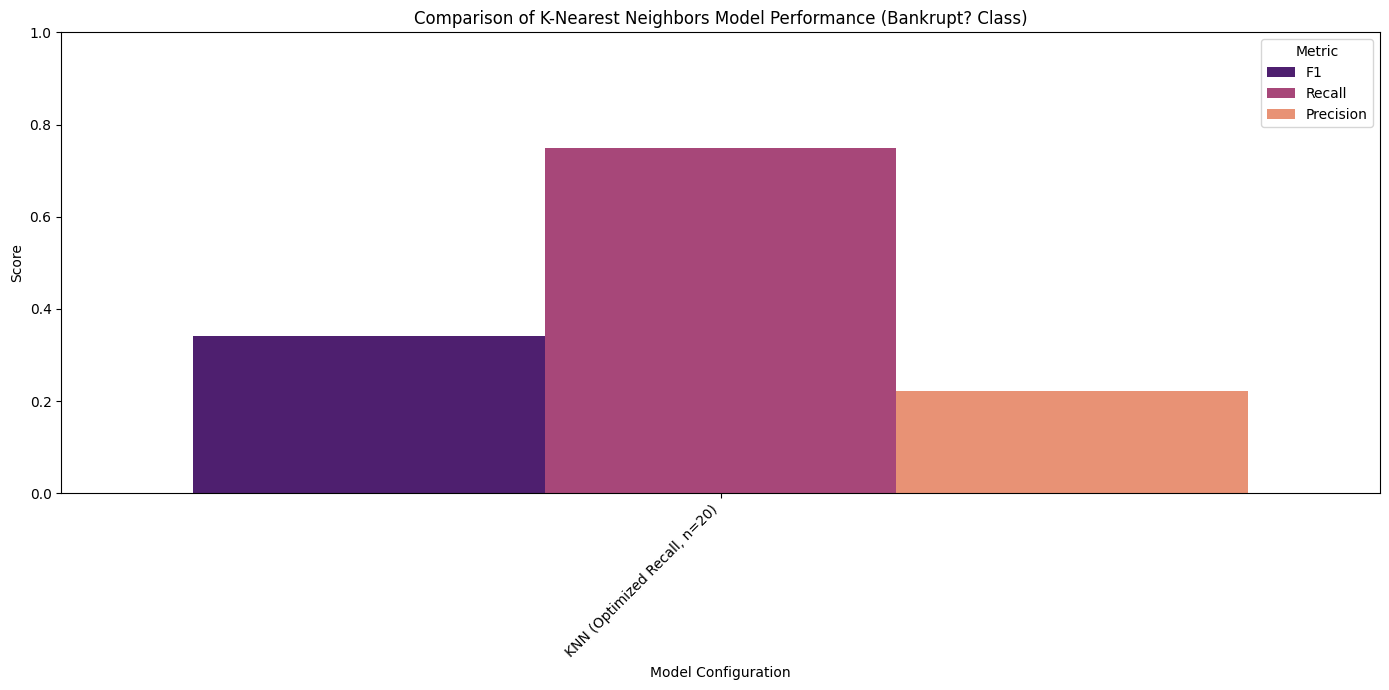


--- Best K-Nearest Neighbors Model Identified ---


In [ ]:
knn_final_results_df = pd.concat(knn_results, ignore_index=True)

print("--- KNN Models Comparison ---")
display(knn_final_results_df)

plt.figure(figsize=(14, 7))
metrics = ['F1', 'Recall', 'Precision']

knn_results_melted = knn_final_results_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

sns.barplot(x='Model', y='Score', hue='Metric', data=knn_results_melted, palette='magma')
plt.title('Comparison of K-Nearest Neighbors Model Performance (Bankrupt? Class)')
plt.ylabel('Score')
plt.xlabel('Model Configuration')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# The best_knn_model_result DataFrame is now defined and will be collected directly by 2e17b4c8
best_knn_model_result = knn_final_results_df.loc[knn_final_results_df['F1'].idxmax()].to_frame().T

# Removed: all_model_results.append(best_knn_model_result) as results will be collected centrally.

print("\n--- Best K-Nearest Neighbors Model Identified ---")


##Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model_dt, result_dt = model_pipeline(
    X_train_vif, y_train, X_test_vif, y_test,
    model=dt_model,
    model_name="Decision Tree (SMOTE + Scaled + Balanced Weight)",
    scale=True,
    use_smote=True
)
# Removed: all_model_results.append(result_dt) as results will be collected centrally.
display(result_dt)


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,Decision Tree (SMOTE + Scaled + Balanced Weight),0.522727,0.196581,0.285714,0.915689,21,23,94,1226,0.477273


In [ ]:
# This cell is now redundant for interim overall results, as consolidation is central in 2e17b4c8.
# Keeping for placeholder if future interim display is needed, but content removed.
# final_overall_results_df = pd.concat(all_model_results, ignore_index=True)
# print("--- Updated Overall Model Results ---")
# display(final_overall_results_df)


Recall is too low compared to previous models

##Random Forest

In [ ]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
model_rf, result_rf = model_pipeline(
    X_train_vif, y_train, X_test_vif, y_test,
    model=rf_model,
    model_name="Random Forest (SMOTE + Scaled + Balanced Weight)",
    scale=True,
    use_smote=True
)
# Removed: all_model_results.append(result_rf) as results will be collected centrally.
display(result_rf)


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,Random Forest (SMOTE + Scaled + Balanced Weight),0.5,0.385965,0.435644,0.958211,22,22,35,1285,0.5


In [ ]:
# This cell is now redundant for interim overall results, as consolidation is central in 2e17b4c8.
# Keeping for placeholder if future interim display is needed, but content removed.
# final_overall_results_df = pd.concat(all_model_results, ignore_index=True)
# print("--- Updated Overall Model Results (including Random Forest) ---")
# display(final_overall_results_df)


##Xgboost

In [ ]:
scale_pos_weight_val = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_val,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05
)

xgb_pipeline = Pipeline([
    ('scale', StandardScaler()), # Added StandardScaler for consistency
    ('model', xgb_model)
])


xgb_pipeline.fit(X_train_vif, y_train)


y_prob_xgb = xgb_pipeline.predict_proba(X_test_vif)[:, 1];


precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb);


precisions = precisions[:-1]
recalls = recalls[:-1]

# Compute F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6);

# Apply recall constraint (>= 0.75)
valid_idxs = np.where(recalls >= 0.75)[0];

if len(valid_idxs) > 0:
    best_idx = valid_idxs[np.argmax(f1_scores[valid_idxs])]
else:
    best_idx = np.argmax(recalls);

best_threshold_xgb = thresholds[best_idx];

print(f"Best Threshold: {best_threshold_xgb:.4f}");

# -------------------------------
# STEP 5: Final predictions
# -------------------------------
y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int);

# -------------------------------
# STEP 6: Metrics
# -------------------------------
cm_xgb = confusion_matrix(y_test, y_pred_xgb);
tn, fp, fn, tp = cm_xgb.ravel();

results_xgb = {
    "Model": "XGBoost (Threshold Tuned for Recall)",
    "Recall": recall_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "F1": f1_score(y_test, y_pred_xgb),
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "False Negatives": fn,
    "True Positives": tp,
    "False Positives": fp,
    "True Negatives": tn,
    "Type 2 Error Rate": fn / (fn + tp)
};

results_xgb_df = pd.DataFrame([results_xgb]);

# Removed: all_model_results.append(results_xgb_df) as results will be collected centrally.

print("\n--- XGBoost Final Results ---");
display(results_xgb_df);


Best Threshold: 0.2748

--- XGBoost Final Results ---


,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
0,XGBoost (Threshold Tuned for Recall),0.75,0.232394,0.354839,0.912023,11,33,109,1211,0.25


/tmp/ipykernel_7323/2226941776.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Type 2 Error Rate', data=error_comparison_df, palette='viridis', label='Type 2 Error Rate')


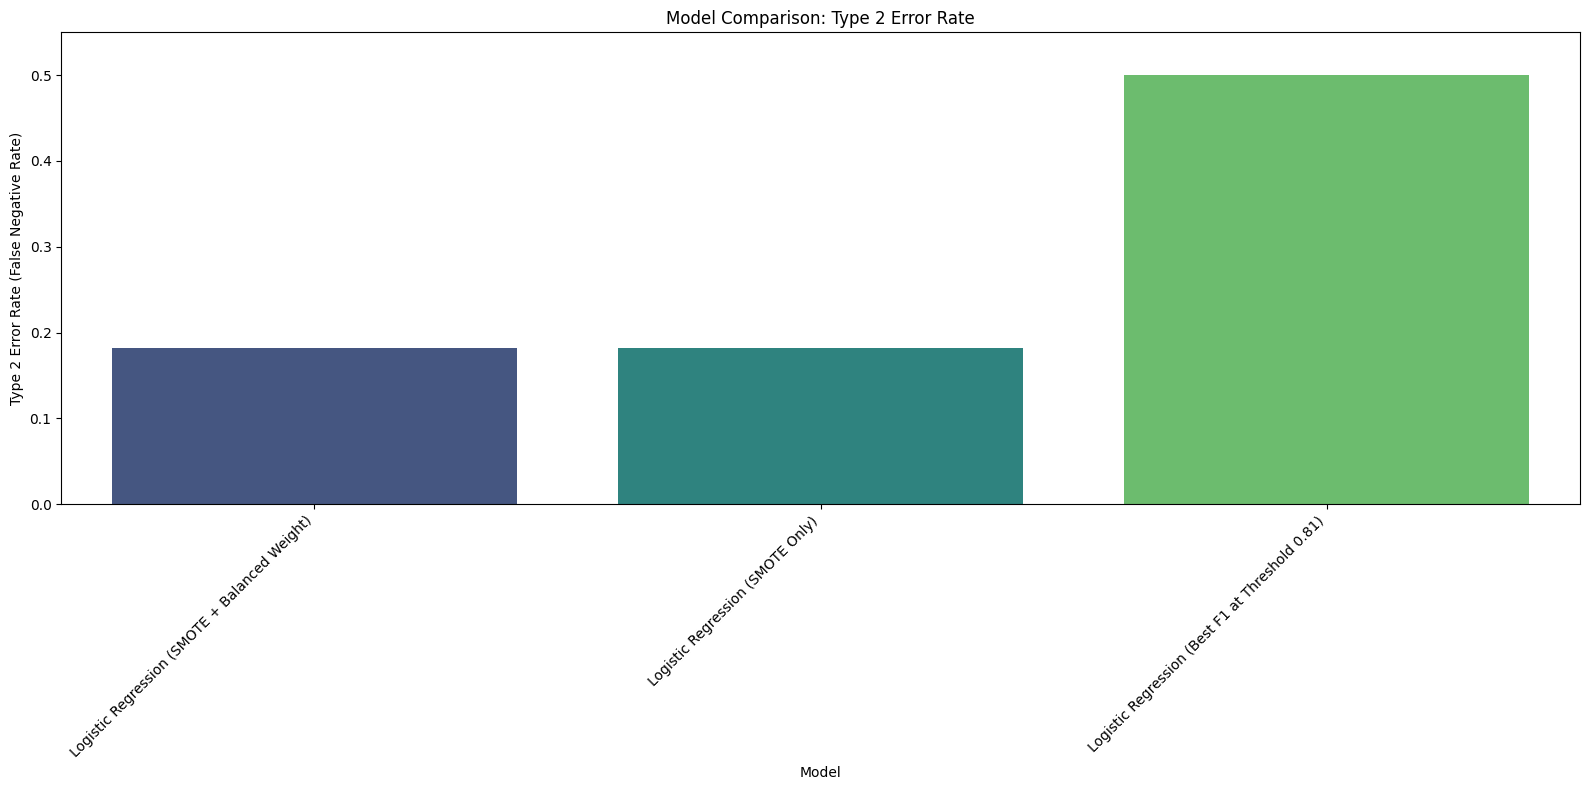

/tmp/ipykernel_7323/2226941776.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='False Negatives', data=error_comparison_df, palette='magma', label='False Negatives')


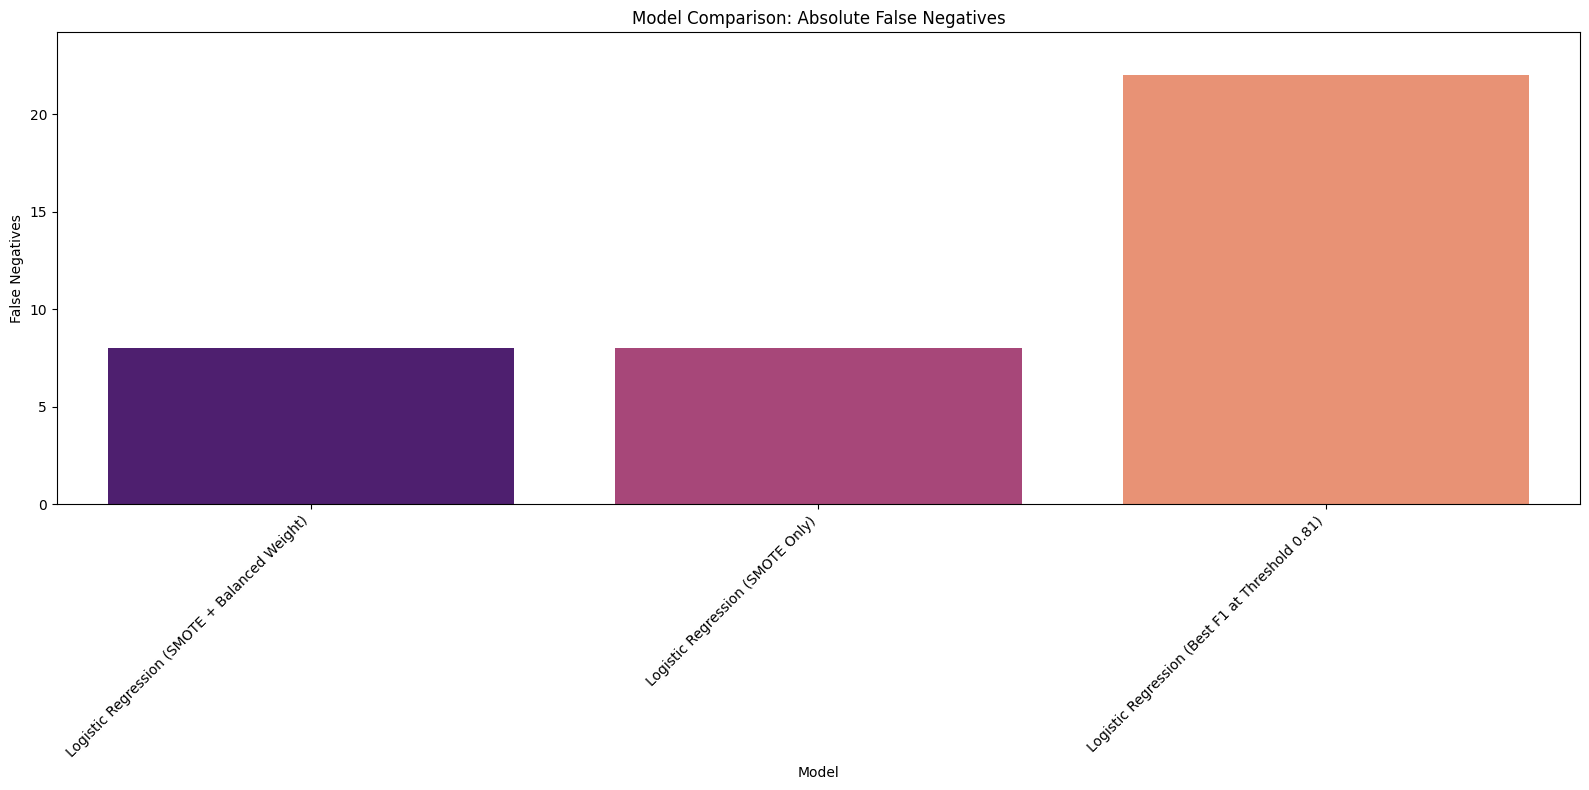

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort models by Type 2 Error Rate for visualization
error_comparison_df = final_overall_results_df.sort_values(by='Type 2 Error Rate', ascending=True)

plt.figure(figsize=(16, 8))

# Bar plot for Type 2 Error Rate
sns.barplot(x='Model', y='Type 2 Error Rate', data=error_comparison_df, palette='viridis', label='Type 2 Error Rate')
plt.ylabel('Type 2 Error Rate (False Negative Rate)')
plt.xlabel('Model')
plt.title('Model Comparison: Type 2 Error Rate')
plt.ylim(0, error_comparison_df['Type 2 Error Rate'].max() * 1.1) # Set y-limit slightly above max for clarity
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))
# Bar plot for False Negatives
sns.barplot(x='Model', y='False Negatives', data=error_comparison_df, palette='magma', label='False Negatives')
plt.ylabel('False Negatives')
plt.xlabel('Model')
plt.title('Model Comparison: Absolute False Negatives')
plt.ylim(0, error_comparison_df['False Negatives'].max() * 1.1) # Set y-limit slightly above max for clarity
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
top_n = 3
top_models_df = final_overall_results_df.sort_values(by='Recall', ascending=False).head(top_n)
display(top_models_df)

,Model,Recall,Precision,F1,Accuracy,False Negatives,True Positives,False Positives,True Negatives,Type 2 Error Rate
1,Logistic Regression (SMOTE + Balanced Weight),0.818182,0.145161,0.246575,0.838710,8,36,212,1108,0.181818
2,Logistic Regression (SMOTE Only),0.818182,0.145161,0.246575,0.838710,8,36,212,1108,0.181818
0,Logistic Regression (Best F1 at Threshold 0.81),0.500000,0.278481,0.357724,0.942082,22,22,57,1263,0.500000


Considering the Recall , F1 and Precision the XGBoost model will be a good choice, in logistic regression model the recall is high but at the same time the precision is too low.